In [ ]:
#Scraping
import urllib.request
url = "https://search.naver.com/search.naver?query=python" #전체: url https: protocol // search~.com : domain / cotextPath / ~? uri / (? 이후)query string
memory = urllib.request.urlopen(url).read()
text = memory.decode("utf-8")
print(text)


<!doctype html> <html lang="ko"><head> <meta charset="utf-8"> <meta name="referrer" content="strict-origin-when-cross-origin">  <meta name="format-detection" content="telephone=no,address=no,email=no"> <meta property="og:title" content="python : 네이버 검색"/> <meta property="og:image" content="https://ssl.pstatic.net/sstatic/search/common/og_v3.png"> <meta property="og:description" content="'python'의 네이버 검색 결과입니다."> <meta name="description" lang="ko" content="'python'의 네이버 검색 결과입니다."> <title>python : 네이버 검색</title> <link rel="shortcut icon" href="https://ssl.pstatic.net/sstatic/search/favicon/favicon_32x32_240820.ico">  <link rel="search" type="application/opensearchdescription+xml" href="https://ssl.pstatic.net/sstatic/search/opensearch-description.https.xml" title="Naver" /><script> if (top.frames.length!=0 || window!=top) window.open(location, "_top"); </script><link rel="stylesheet" type="text/css" href="https://ssl.pstatic.net/sstatic/search/pc/css/search1_250529.css"> <link rel="styl

검색 단어를 입력하세요logitec
url= https://search.naver.com/search.naver?query=logitec
<!doctype html> <html lang="ko"><head> <meta charset="utf-8"> <meta name="referrer" content="strict-origin-when-cross-origin">  <meta name="format-detection" content="telephone=no,address=no,email=no"> <meta property="og:title" content="logitec : 네이버 검색"/> <meta property="og:image" content="https://ssl.pstatic.net/sstatic/search/common/og_v3.png"> <meta property="og:description" content="'logitec'의 네이버 검색 결과입니다."> <meta name="description" lang="ko" content="'logitec'의 네이버 검색 결과입니다."> <title>logitec : 네이버 검색</title> <link rel="shortcut icon" href="https://ssl.pstatic.net/sstatic/search/favicon/favicon_32x32_240820.ico">  <link rel="search" type="application/opensearchdescription+xml" href="https://ssl.pstatic.net/sstatic/search/opensearch-description.https.xml" title="Naver" /><script> if (top.frames.length!=0 || window!=top) window.open(location, "_top"); </script><link rel="stylesheet" type="text/css" href="h
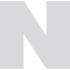
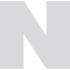

In [ ]:
import urllib.request
import urllib.parse
url = "https://search.naver.com/search.naver"
queryText = input("검색 단어를 입력하세요")
value = {"query" : queryText}
params = urllib.parse.urlencode(value) #dictionary를 query string으로 변경
url = url + "?" + params
print("url=", url)
memory = urllib.request.urlopen(url).read()
text = memory.decode("utf-8")
print(text)


In [ ]:
text = '''
<html><body>
  <h1>제목</h1>
  <p>내용1</p>
  <p>내용2</p>
</body></html>
'''


from bs4 import BeautifulSoup #crowling module
soup = BeautifulSoup(text, "html.parser") #생성자 / utf-8 > html 변환
print(soup)
h1 = soup.html.h1
print(h1.string)
p = soup.html.p.string
print(p)
p2 = soup.html.p.next_sibling.next_sibling # = soup.html.body.p.next_sibling.next_sibling = soup.body.p.next_sibling.next_sibling
print(p2.string)


<html><body>
<h1>제목</h1>
<p>내용1</p>
<p>내용2</p>
</body></html>

제목
내용1
내용2


In [ ]:
text = '''
<html><body>
  <h1 id='title'>제목</h1>
  <p id='content'>내용1</p>
  <p href = 'a.html' alt=''>내용2</a></p>
</body></html>
'''

from bs4 import BeautifulSoup
soup = BeautifulSoup(text, "html.parser")
a1 = soup.html.a
print(a1)
content = soup.find(id = 'content')
print(content)
title = soup.find(id='title')
print(title.string)
attrs = soup.body.a.attrs
print(attrs)
print(attrs['href'])

None
<p id="content">내용1</p>
제목


AttributeError: 'NoneType' object has no attribute 'attrs'

In [ ]:
#Scraping
import urllib.request as req
url = "https://finance.naver.com/marketindex/"
memory = req.urlopen(url)
print(memory)

#Crawling
from bs4 import BeautifulSoup
soup = BeautifulSoup(memory, "html.parser")
print("#exchangeList > li.on > a.head.usd > div > span.value") #선택자 = selector
##exchangeList > li.on > a.head.jpy > div > span.value
##exchangeList > li.on > a.head.eur > div > span.value
price = soup.select_one("#exchangeList > li.on > a.head.usd > div > span.value")
print(price.string)
prices = soup.select("div > span.value") #반복되는 태그는 모두 가져올 수 있음
for pri in prices:
  print(pri.string)

#exchangeList > li.on > a.head.usd > div > span.value
1,389.50
1,389.50
942.64
1,628.63
194.98
147.0700
1.1735
1.3520
97.7200
61.87
1659.32
3653.3
160539.23


In [ ]:
text = """
<html><body>
<h1>위키북스 도서1111111</h1>
<div>
    <h1>이숭무</h1>
</div>
<div id="meigen">
  <h1>위키북스 도서</h1>
  <ul class="items">
    <li>유니티 게임 이펙트 입문</li>
    <li>스위프트로 시작하는 아이폰 앱 개발 교과서</li>
    <li>모던 웹사이트 디자인의 정석</li>
  </ul>
</div>
</body></html>
"""

from bs4 import BeautifulSoup
soup = BeautifulSoup(text, "html.parser")
h1 = soup.body.h1
print(h1)
h2 = soup.find(id="meigen").h1
print(h2)
h3 = soup.find("h1")
print(h3)
div = soup.find("div").h1
print(div)
div = soup.body.div.h1
print(div)
div = soup.select_one("div#meigen")
print(div)
h1 = soup.select_one("div#meigen > h1")
print(h1)
ul = soup.select_one("div#meigen > ul")
print(ul)
li = soup.select_one("div#meigen > ul > li")
print(li)
lis = soup.select_one("ul.items > li")
print(lis)
for li in lis:
  print(li.string)
lis = soup.select_one("div#meigen  li") #공백은 하위(자식, 손자)를 모두 포함
print(lis)
for li in lis:
  print(li.string)

<h1>위키북스 도서1111111</h1>
<h1>위키북스 도서</h1>
<h1>위키북스 도서1111111</h1>
<h1>이숭무</h1>
<h1>이숭무</h1>
<div id="meigen">
<h1>위키북스 도서</h1>
<ul class="items">
<li>유니티 게임 이펙트 입문</li>
<li>스위프트로 시작하는 아이폰 앱 개발 교과서</li>
<li>모던 웹사이트 디자인의 정석</li>
</ul>
</div>
<h1>위키북스 도서</h1>
<ul class="items">
<li>유니티 게임 이펙트 입문</li>
<li>스위프트로 시작하는 아이폰 앱 개발 교과서</li>
<li>모던 웹사이트 디자인의 정석</li>
</ul>
<li>유니티 게임 이펙트 입문</li>
<li>유니티 게임 이펙트 입문</li>
유니티 게임 이펙트 입문
<li>유니티 게임 이펙트 입문</li>
유니티 게임 이펙트 입문
